# messing around with decomposing l05 into large & small scales


In [9]:
import numpy as np 
import sys
sys.path.insert(0, '..')
import DAPyr as dap
import matplotlib.pyplot as plt
from importlib import reload
from scipy.stats import norm, cauchy
from scipy.io import loadmat

from DAPyr.MISC import rkhs_likelihood, diff_map_ext_nystrom
from DAPyr.MODELS import deconstruct_Z_circulant
from ipywidgets import *

reload(dap)

np.set_printoptions(suppress=True)


In [6]:
uoep = {'mu': 0, 'sigma': 0.5} 
poep = {'mu': 0, 'sigma': 0.5} 
uoep_small_sc = {'mu': 0, 'sigma': 0.01} 
poep_small_sc = {'mu': 0, 'sigma': 0.01} 
poep_gaus_lg = {'mu': 0, 'sigma': 1.8} 
poep_gaus_cauchy = {'mu': 0, 'sigma': 0.5} 
# original experiments were gamma = 0.2!
uoep_cauchy = {'x0': 0, 'gamma': 0.34}
poep_cauchy = {'x0': 0, 'gamma': 0.34} 

uoep_logistic = {'x0': 0, 'scale' : 1}
poep_logistic = {'x0': 0, 'scale' : 1} 

uoep_sd = {'mu1': -2.0, 'sigma1': 1, 'mu2': 2.0, 'sigma2':1, 'threshold': 0}
poep_sd = {'mu1': -2.0, 'sigma1': 1, 'mu2': 2.0, 'sigma2':1, 'threshold': 0}

params = {'s': 10, 'r': 28, 'b':8/3, 'F': 8, 
          'l05_F':15, 'l05_Fe':15,
          'l05_K':32, 'l05_I':12, 
          'l05_b':10.0, 'l05_c':2.5}



## crack at data driven approach. 

In [7]:
e_name = 'l05-kecd-split_full'
print(f'starting experiment {e_name}')
knn = 0.1
# original experiments!
e_sd_kecd = dap.Expt(e_name, {'expt_flag': 3,
                       'model_flag':2,
                       'localize':1,
                       'obf': 10,
                       'seed': 58,
                       'qc_flag': 0,
                       'h_flag': 0,
                       'used_obs_err': 0,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep,
                       'prescribed_obs_err_params': poep,
                       'save_keest_pab':1,
                       'Ne':80,
                       'T': 1000,
                       'split_l05_state': True,
                       'train_large_scale': True,
                       'T_train': 250,
                       'nle_type': 4,
                       'Nb': 16,
                       'small_win': 4,
                       'nle_every': 10000, 
                       'Neig': 50,
                       'knn_frac': knn,
                       'bw_dm': 'knn_adaptive',
                       'debug_nle_noDA': False})



starting experiment l05-kecd-split_full


python(3245) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3246) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3247) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3248) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3249) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3250) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3251) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3252) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3253) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3254) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3255) MallocStackLoggin

In [10]:
dap.runDA(e_sd_kecd)
#e_sd_kecd.saveExpt()

KeyError: 'atx is not a file in the archive'

<Axes: title={'center': 'Conditional Distribution Estimates for Experiment l05-kecd-split_full'}, xlabel='$y$', ylabel='$p(y | x)$'>

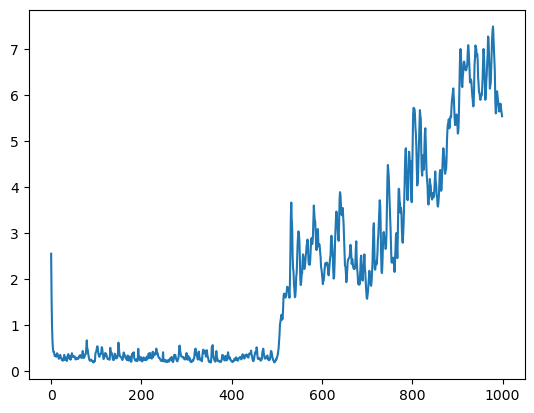

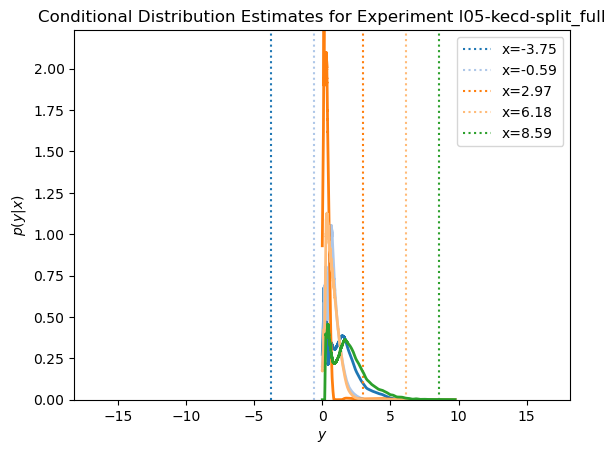

<Figure size 640x480 with 0 Axes>

In [6]:
plt.plot(e_sd_kecd.rmse)
dap.plot_pab(e_sd_kecd, plot_states=True)

### do my embeddings look reasonable? let's take a look:

In [5]:
embs = np.load('multivar_emb.npz')
embs_l = np.load('multivar_emb_large.npz')
#for key in embs:
#    print(f'{key} with shape {embs[key].shape}')
x_emb = embs['x_emb']
y_emb = embs['y_emb']
evec_x = embs['evec_x']
evec_y = embs['evec_y']
eval_x = embs['eval_x']
eval_y = embs['eval_y']
bwx = embs['bwx']
bwy = embs['bwy']
x_train = embs['x_train']
y_train = embs['y_train']
a_train_x = embs['a_train_x']
a_train_y = embs['a_train_y']


lx_emb = embs_l['x_emb']
ly_emb = embs_l['y_emb']
levec_x = embs_l['evec_x']
levec_y = embs_l['evec_y']
leval_x = embs_l['eval_x']
leval_y = embs_l['eval_y']
lbwx = embs_l['bwx']
lbwy = embs_l['bwy']
lx_train = embs_l['x_train']
ly_train = embs_l['y_train']
la_train_x = embs_l['a_train_x']
la_train_y = embs_l['a_train_y']

In [6]:
def quadratic(x,a,b,c):
    return a*x*x + b*x + c

def plot_state_and_embs(n, ev1, ev2, large_only, x_or_y, sample_nystrom, a, b, c, find_nearest):
    fig, axs = plt.subplots(1,2, figsize=(10,5))

    if x_or_y == 'x':
        if not large_only:
            plotme_train = x_train
            plotme_embs = x_emb
            vec = evec_x
            val = eval_x
            bw = bwx
            a_train = a_train_x
        else:
            plotme_train = lx_train
            plotme_embs = lx_emb
            vec = levec_x
            val = leval_x
            bw = lbwx
            a_train = la_train_x
    else:
        if not large_only:
            plotme_train = y_train
            plotme_embs = y_emb
            vec = evec_y
            val = eval_y
            bw = bwy
            a_train = a_train_y
        else:
            plotme_train = ly_train
            plotme_embs = ly_emb
            vec = levec_y
            val = leval_y
            bw = lbwy
            a_train = la_train_y

    a_train = np.asarray(a_train).squeeze()

    ## plot training data points

    if x_or_y == 'x':
        axs[0].plot(plotme_train[:,n], c='C1', label=f'training point {n}')
        axs[0].set_ylim(-10,20)
    else:
        axs[0].scatter(plotme_train[:,n], 0, c='C1', label=f'training point {n}')
        axs[0].plot([1e-3, 2], [0,0], c='C1')
        axs[0].set_xlim(1e-3,2)
        axs[0].set_xscale('log')
        
    ## plot DM embeddings
        
    axs[1].scatter(plotme_embs[ev1], plotme_embs[ev2], s=2)
    axs[1].scatter(plotme_embs[ev1, n], plotme_embs[ev2,n], c='C1', label='training embedding')
    axs[1].set_xlabel(f'EV {ev1}')
    axs[1].set_ylabel(f'EV {ev2}')

    ## plot OOSE via nystrom from sample point

    if sample_nystrom:
        if x_or_y == 'x':
            sample = quadratic(np.arange(33), a,b,c).reshape(1,-1)
            oose_emb = diff_map_ext_nystrom(sample,
            plotme_train.T,
            vec,
            val,
            a_train,
            bw,
            2401, 
            33)

            axs[0].plot(sample[0], c='black', label='OOSE input')
            sample_emb = (oose_emb * val).T
            axs[1].scatter(sample_emb[ev1], sample_emb[ev2], c='black', label='OOSE emb')

            if find_nearest:
                ind = np.argmin(np.sum((sample_emb - plotme_embs) ** 2, axis=0))
                axs[0].plot(plotme_train[:,ind], c='C3', label=f'training closest to OOSE: {ind}')
                axs[1].scatter(plotme_embs[ev1,ind], plotme_embs[ev2, ind], c='C3', label=f'emb of training closest to OOSE: {ind}')

        else:
            
            oose_emb = diff_map_ext_nystrom(np.array([[a]]),
            plotme_train.T,
            vec,
            val,
            a_train,
            bw,
            2401, 
            1)

            axs[0].scatter(a, 0, c='black')
            sample_emb = (oose_emb * val).T
            axs[1].scatter(sample_emb[ev1], sample_emb[ev2], c='black')
            
            if find_nearest:
                ind = np.argmin(np.sum((sample_emb - plotme_embs) ** 2, axis=0))
                axs[0].scatter(plotme_train[:,ind], 0, c='C3', label=f'training closest to OOSE: {ind}')
                axs[1].scatter(plotme_embs[ev1,ind], plotme_embs[ev2, ind], c='C3', label=f'emb of training closest to OOSE: {ind}')
            

    ## clean things up
    
    plt.tight_layout()
    axs[0].legend(loc=1)
    axs[1].legend(loc=1)
    

interact(
    plot_state_and_embs,
    n=IntSlider(min=0, max=23999, step=1, value=0),
    ev1=IntSlider(min=0, max=50, step=1, value=2),
    ev2=IntSlider(min=0, max=50, step=1, value=3),
    large_only=Checkbox(options=['True','False'], description='Training on large only:'),
    sample_nystrom=Checkbox(options=['True','False'], description='OOSE Point?:'),
    find_nearest=Checkbox(options=['True','False'], description='Nearest training point to OOS input:'),
    x_or_y = RadioButtons(options=['x','y'], description='x or y?'),
    a = FloatSlider(min=-1, max=1, step=0.01, value=0),
    b = FloatSlider(min=-10, max=10, step=0.01, value=0),
    c = FloatSlider(min=-10, max=20, step=0.1, value=0),
);

#nystrom ext constructed curves!

interactive(children=(IntSlider(value=0, description='n', max=23999), IntSlider(value=2, description='ev1', ma…

### this doesn't seem very good (see below)

## OK - what about assimilating these obs directly, with knowledge of the correct forward operator?

### After fixing some numerical stuff in the LPF, I am tracking experiments that JP has come up with for this case. Good parameters for this experiment seem to be obf = 10, small_win=4, roi=0.02 (double what it was for the other experiments). The output of that experiment (and the same one with roi=0.015) are in data/experiments/scale-sep

starting experiment l05-noda-split-c25
10
4
0.015
DB: Starting cycle 0


/Users/etto/research/DAPyr-nle/src/notebooks/../DAPyr/DA.py:241: RuntimeWarning: divide by zero encountered in log
  
/Users/etto/research/DAPyr-nle/src/notebooks/../DAPyr/DA.py:261: RuntimeWarning: divide by zero encountered in log
  break


DB: Starting cycle 100
DB: Starting cycle 200
DB: Starting cycle 300
DB: Starting cycle 400
DB: Starting cycle 500
DB: Starting cycle 600
DB: Starting cycle 700
DB: Starting cycle 800
DB: Starting cycle 900
DB: Starting cycle 1000
DB: Starting cycle 1100
DB: Starting cycle 1200
DB: Starting cycle 1300
DB: Starting cycle 1400
DB: Starting cycle 1500
DB: Starting cycle 1600
DB: Starting cycle 1700
DB: Starting cycle 1800
DB: Starting cycle 1900
1.9107740644165938
10
4
0.02
DB: Starting cycle 0


/Users/etto/research/DAPyr-nle/src/notebooks/../DAPyr/DA.py:241: RuntimeWarning: divide by zero encountered in log
  
/Users/etto/research/DAPyr-nle/src/notebooks/../DAPyr/DA.py:261: RuntimeWarning: divide by zero encountered in log
  break


DB: Starting cycle 100
DB: Starting cycle 200
DB: Starting cycle 300
DB: Starting cycle 400
DB: Starting cycle 500
DB: Starting cycle 600
DB: Starting cycle 700
DB: Starting cycle 800
DB: Starting cycle 900
DB: Starting cycle 1000
DB: Starting cycle 1100
DB: Starting cycle 1200
DB: Starting cycle 1300
DB: Starting cycle 1400
DB: Starting cycle 1500
DB: Starting cycle 1600
DB: Starting cycle 1700
DB: Starting cycle 1800
DB: Starting cycle 1900
1.8268620076652702


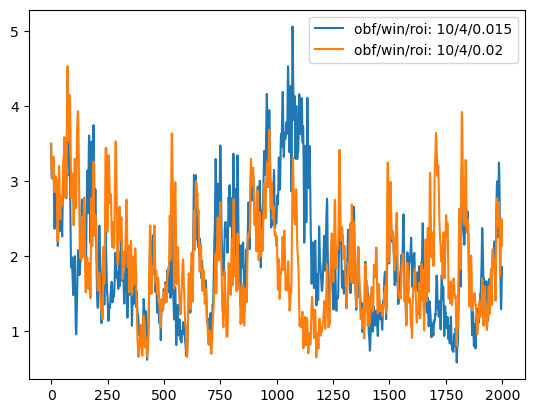

In [297]:
print(f'starting experiment {e_name}')
#bw = 0.02
#knn = 0.1
klb=0.0
obfs = np.array([10])
small_wins = np.array([4])
rois = np.array([0.02])

#obfs = np.array([10])
#small_wins = np.array([4])
#rois = np.array([0.015])

e_split_true = dap.Expt(f'e_roi_{roi}', {'expt_flag': 1,
                       'model_flag':2,
                       'model_params': params,
                       'localize':1,
                       'obf': obf,
                       'seed': 58,
                       'h_flag': 3,
                       'roi': roi,
                       'Nt_eff': 0.8,
                       'used_obs_err': 0,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep_small_sc,
                       'prescribed_obs_err_params': poep_small_sc,
                       'save_keest_pab':1,
                       'small_win': small_win,
                       'kddm_flag': 1,
                       'Ne':80,
                       'T': 2000,
                       'saveForecastEns': True,
                       'saveEnsMean': True})

e_name = 'l05-noda-split-c25'
e_split_noda = dap.Expt(e_name, {'expt_flag': 2,
                       'model_flag':2,
                       'model_params': params,
                       'localize':1,
                       'seed': 58,
                       'h_flag': 3,
                       'save_keest_pab':1,
                       'force_hx_identity': False,
                       'Ne':80,
                       'T': 2000,
                       'split_l05_state': False,
                       'saveForecastEns': True,
                       'saveEnsMean': True,
                       'debug_nle_noDA': False})

In [298]:
dap.runDA(e_split_noda)
dap.runDA(e_split_true)
e_split_true.saveExpt()
e_split_noda.saveExpt()

DB: Starting cycle 0
DB: Starting cycle 100
DB: Starting cycle 200
DB: Starting cycle 300
DB: Starting cycle 400
DB: Starting cycle 500
DB: Starting cycle 600
DB: Starting cycle 700
DB: Starting cycle 800
DB: Starting cycle 900
DB: Starting cycle 1000
DB: Starting cycle 1100
DB: Starting cycle 1200
DB: Starting cycle 1300
DB: Starting cycle 1400
DB: Starting cycle 1500
DB: Starting cycle 1600
DB: Starting cycle 1700
DB: Starting cycle 1800
DB: Starting cycle 1900


'completed'

In [308]:
e_split_true = dap.loadExpt('data/experiments/scale-sep/e_roi_0.02.expt')
e_split_noda = dap.loadExpt('data/experiments/scale-sep/l05-noda-split-c25.expt')

def plot_scale_sep(t, ne, lowc, show_small_scales, show_fens_member, show_noda_ens, show_obs, show_aens_member, show_truth, show_ens_mean, show_noda_mean):

    if lowc:
        xf = e_split_true_lowc.x_fore_ens
        xa = e_split_true_lowc.x_ens
        xt = e_split_true_lowc.getStates()[1]
        Y = e_split_true_lowc.getStates()[2]
        xam = e_split_true_lowc.x_ensmean
    else:
        xf = e_split_true.x_fore_ens
        xa = e_split_true.x_ens
        xt = e_split_true.getStates()[1]
        Y = e_split_true.getStates()[2]
        xam = e_split_true.x_ensmean

    if show_truth:
        plt.plot(xt[:,t], c='k', label='truth')
        if show_obs:
            plt.scatter(np.arange(0,480,obf), Y[:,t,:], c='k', s=6)

    if show_fens_member:
        xf_smallscale = deconstruct_Z_circulant(xf[:,:,t])[1]
        hx = dap.MISC.h_weighted_mat(xf_smallscale, obf, small_win)
        if show_obs:
            plt.scatter(np.arange(0,480,obf), hx[:, ne], c='r', s=6)
        plt.plot(xf[:,ne,t], c='r', label=f'bg ens member {ne}')
        
    if show_aens_member:
        xa_smallscale = deconstruct_Z_circulant(xa[:,:,t])[1]
        hxa = dap.MISC.h_weighted_mat(xa_smallscale, obf, small_win)
        if show_obs:
            plt.scatter(np.arange(0,480,obf), hxa[:, ne], c='blue', s=6)
        plt.plot(xa[:,ne,t], c='blue', label=f'post ens member {ne}')

    if show_small_scales:
        if show_truth:
            xt_smallscale = deconstruct_Z_circulant(xt)[1]
            plt.plot(xt_smallscale[:,t], c='k', linewidth=1)
        if show_fens_member:
            plt.plot(xf_smallscale[:,ne], c='r', linewidth=1)
        if show_aens_member:
            plt.plot(xa_smallscale[:,ne], c='blue', linewidth=1)

    if show_ens_mean:
        plt.plot(xam[:,t], label='ens mean')
        
    if show_noda_mean:
        if lowc:
            plt.plot(e_split_noda_lowc.x_ensmean[:,t], label='noda mean')
        else:
            plt.plot(e_split_noda.x_ensmean[:,t], label='noda mean')

    if show_noda_ens:
        xa_noda = e_split_noda.x_ens
        plt.plot(xa_noda[:,ne,t], c='magenta', label = f'noda member {ne}')
        
        
    
    plt.legend(loc=4)
    plt.ylim(-10, 16)


interact(
    plot_scale_sep,
    t=IntSlider(min=1, max=1999, step=1, value=0),
    ne=IntSlider(min=1, max=79, step=1, value=0),
    show_small_scales=Checkbox(options=['True','False'], description='plot small scale:'),
    lowc=Checkbox(options=['True','False'], description='Low coupling:'),
    show_obs=Checkbox(options=['True','False'], description='plot obs space quantities:'),
    show_fens_member=Checkbox(options=['True','False'], description='plot forecast ensemble member:'),
    show_aens_member=Checkbox(options=['True','False'], description='plot analysis ensemble member:'),
    show_ens_mean=Checkbox(options=['True','False'], description='plot ensemble mean:'),
    show_noda_mean=Checkbox(options=['True','False'], description='plot noda mean:'),
    show_noda_ens=Checkbox(options=['True','False'], description='plot noda ens members:'),
    show_truth=Checkbox(options=['True','False'], description='plot truth and obs:', value=True),
);
print(e_split_true.x_ensmean.shape)


interactive(children=(IntSlider(value=1, description='t', max=1999, min=1), IntSlider(value=1, description='ne…

(480, 2000)


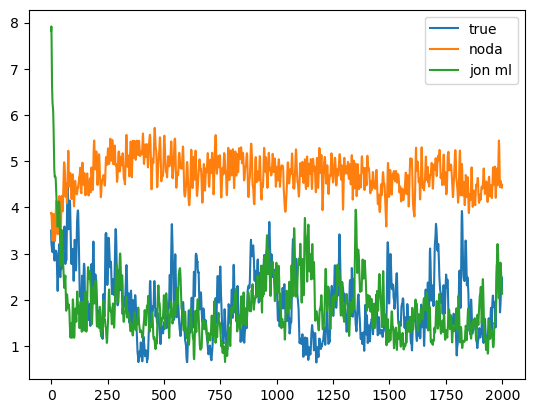

In [310]:
m_long_mat = loadmat('data/experiments/scale-sep/l05_c25.mat')
plt.plot(e_split_true.rmse, label='true')
plt.plot(e_split_noda.rmse, label='noda')
plt.plot(m_long_mat['data']['err'][0][0][0][0][0], label='jon ml')
plt.legend()

## INITIAL CONSTRUCTION OF SMALL STATE FORWARD OPERATOR/PICKING OUT TRAINING X INTERVALS

In [124]:
def h_weighted_mat(Y, h, w=3):
    Y = np.asarray(Y)
    N,k = Y.shape
    
    # 1. Determine the center indices for each step
    centers = np.arange(0, N, h)[:, np.newaxis] # Shape: (M, 1)
    
    # 2. Create the window offsets
    offsets = np.arange(-w, w + 1)              # Shape: (2w + 1,)
    
    # 3. Compute all target indices using broadcasting and modulo for periodicity
    # Shape: (M, 2w + 1)
    target_indices = (centers + offsets) % N
    
    # 4. Construct the transformation matrix W of shape (M, N)
    M = len(centers)
    W = np.zeros((M, N))
    
    # Row-by-row, add 1 to the positions specified by target_indices
    row_indices = np.arange(M)[:, np.newaxis]
    np.add.at(W, (row_indices, target_indices), 1)
    
    # 5. The single matrix operation applied to |Y|
    return W @ np.abs(Y)

def x_slices(X, h, w):
    X = np.asarray(X)
    N = len(X)
    
    # 1. Determine the center indices and window offsets
    centers = np.arange(0, N, h)[:, np.newaxis] # Shape: (M, 1)
    offsets = np.arange(-w, w + 1)              # Shape: (2w + 1,)
    
    # 2. Compute periodic target indices
    # Shape: (M, 2w + 1)
    target_indices = (centers + offsets) % N
    M, window_size = target_indices.shape
    
    # 3. Construct the Selection Matrix P of shape (M * window_size, N)
    total_extracted_elements = M * window_size
    P = np.zeros((total_extracted_elements, N))
    
    # Map each position in the flattened output to its corresponding index in X
    row_indices = np.arange(total_extracted_elements)
    col_indices = target_indices.ravel() # Flatten the target indices
    P[row_indices, col_indices] = 1
    
    # 4. Apply the matrix operation and reshape into the final matrix grid
    flat_slices = P @ X
    return flat_slices.reshape(M, window_size)

import numpy as np

def periodic_window_context(X, h, w):
    X = np.asarray(X)
    N = len(X)
    
    # 1. Determine center indices and window offsets
    centers = np.arange(0, N, h)[:, np.newaxis] # Shape: (M, 1)
    offsets = np.arange(-w, w + 1)              # Shape: (1, 2w + 1)
    
    # 2. Compute periodic target indices
    targets = (centers + offsets) % N           # Shape: (M, 2w + 1)
    M = len(centers)
    
    # 3. Construct the Context Selection Matrix P of shape (M * N, N)
    # Initialize the entire matrix with np.nan
    P = np.full((M * N, N), np.nan)
    
    # Calculate which global row indices in P correspond to valid window placements
    step_indices = np.arange(M)[:, np.newaxis]
    rows = (step_indices * N + targets).ravel()
    cols = targets.ravel()
    
    # For active rows, initialize them to 0, then set the target column to 1
    P[rows, :] = 0
    P[rows, cols] = 1
    
    # 4. Perform the single matrix multiplication and reshape to (M, N)
    flat_context = P @ X
    return flat_context.reshape(M, N)

def deconstruct_Z_circulant(Zn_matrix, I=12):
    Zn_matrix = np.asarray(Zn_matrix)
    Nx, k_cols = Zn_matrix.shape
    I = int(I)
    
    if I > 1:
        alpha = (3*I*I + 3)/(2*I*I*I + 4*I)
        beta = (2*I*I + 1)/(I*I*I*I + 2*I*I)
        
        # 1. Create the base filter weights
        offsets = np.arange(-I, I + 1)
        weights = alpha - beta * np.abs(offsets)
        weights[0] /= 2
        weights[-1] /= 2
        
        # 2. Map weights to a baseline row of length Nx using periodic modulo
        base_row = np.zeros(Nx)
        np.add.at(base_row, offsets % Nx, weights)
        
        # 3. Generate the Nx x Nx Circulant Transformation Matrix
        rows = np.arange(Nx)[:, np.newaxis]
        cols = np.arange(Nx)
        C = base_row[(cols - rows) % Nx]
        
        # 4. Apply the single matrix multiplication to all columns at once
        # (Nx x Nx) @ (Nx x k_cols) -> (Nx x k_cols)
        Xn = C @ Zn_matrix
        Yn = Zn_matrix - Xn
    else:
        Xn = Zn_matrix.copy()
        Yn = np.zeros_like(Zn_matrix)
        
    return Xn, Yn

### demo plotting - see file location

In [82]:
#for num in range(120):
#   xs = periodic_window_context(X, 4, 10)
#   plt.plot(ens1, linewidth=2, c='k')
#   plt.plot(X, c='red')
#   plt.plot(Y)
#   plt.plot(xs[num], linewidth=6, c='red')
#   plt.plot((num*4, num*4), (0,2*hy[num]), linewidth=1, c='C1')
#   plt.scatter(num*4, 2*hy[num], c='C1')
#   plt.savefig(f'../figs/l05-multiscale/demo-l05-multiscale-{num:03}.png')
#   plt.close()